# Asteroids date comparison for NASA Sentry and ESA Risk List
Written by Jackey Fang<br>
<br>
**Last Update**<br>
2026-02-22

# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import re
from astropy.table import QTable, vstack

# Comparing date range of both sets|

## Selecting years only columns

In [2]:
def date_grab(sum_table):
    if 'object_name' in sum_table.colnames:
        # ESA Table
        target_col = sum_table['object_name']
    elif 'fullname' in sum_table.colnames:
        # NASA Table
        target_col = sum_table['fullname']
    else:
        print("Error: Could not find 'object_name' or 'fullname' column.")
        return None

    year_list = []
    
    for name in target_col:
        name_str = str(name).strip()
        match = re.search(r'(19|20)\d{2}', name_str)
        
        if match:
            year_list.append(int(match.group()))
        else:
            year_list.append(-1) 
            
    return year_list

In [3]:
NASA_SENTRY_table_sum = QTable.read('data/nasa_ipcum.ecsv', format='ascii.ecsv')
ESA_table_sum = QTable.read('data/esa_ipcum.ecsv', format='ascii.ecsv')
nasa_year = date_grab(NASA_SENTRY_table_sum)
esa_year = date_grab(ESA_table_sum)

nasa_year_table = QTable()
nasa_year_table['nasa'] = nasa_year
esa_year_table = QTable()
esa_year_table['esa'] = esa_year

## Plotting years hist

In [4]:
# Combined dates
all_year = np.concatenate([nasa_year, esa_year])

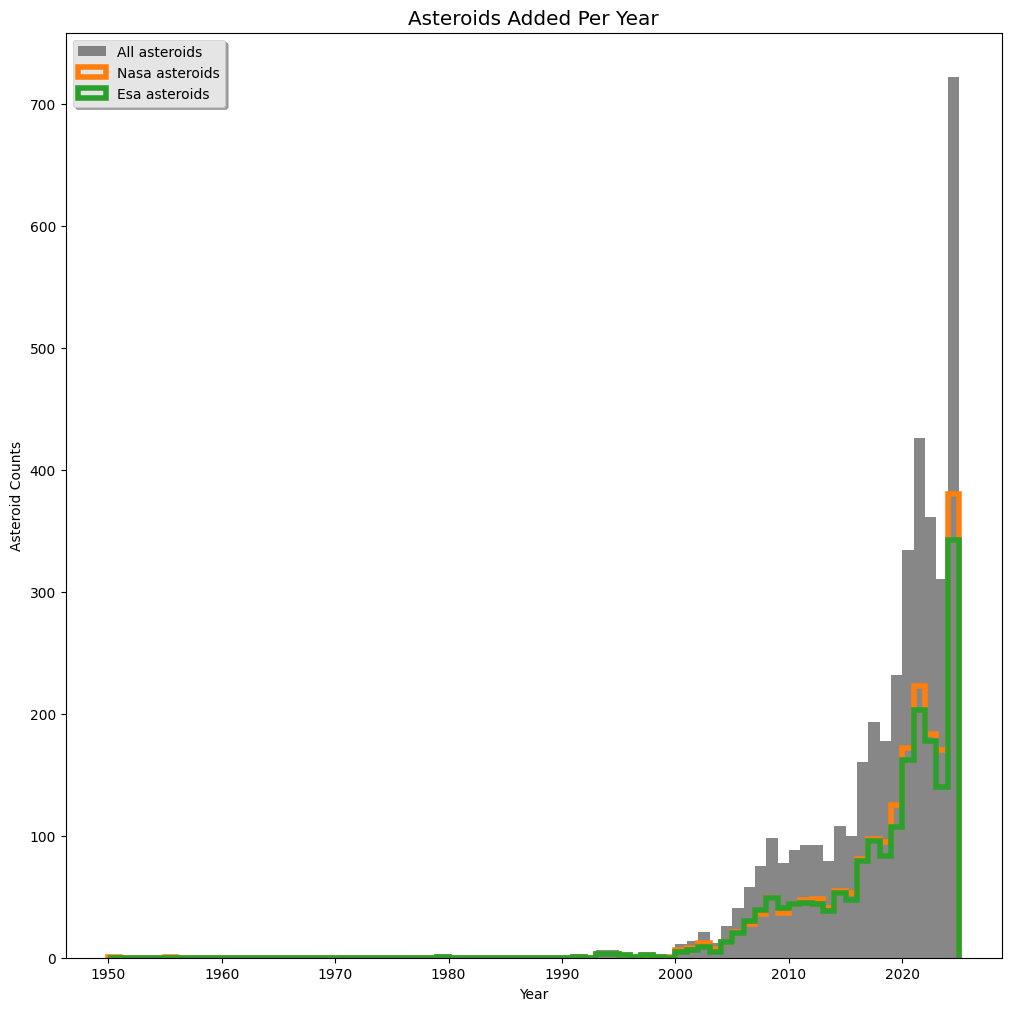

In [5]:
fig, ax = plt.subplots(
    figsize = (10, 10), 
    constrained_layout = True,
)

plt.style.use('ggplot')

# All asteroids
my_bins = np.arange(1950, 2026, 1)

ax.hist(all_year,
           bins = my_bins,
           histtype = 'stepfilled',
           facecolor = 'DimGray',
           alpha = 0.8,
           label = "All asteroids")

# Nasa
ax.hist(nasa_year_table['nasa'],
           bins = my_bins,
           histtype = 'step',
           facecolor = 'blue',
           linewidth = 4,
           label = "Nasa asteroids")
# Esa
ax.hist(esa_year_table['esa'],
           bins = my_bins,
           histtype = 'step',
           facecolor = 'red',
           linewidth = 4,
           label = "Esa asteroids")

ax.set_title("Asteroids Added Per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Asteroid Counts")

ax.legend(loc=0, shadow=True);

### Zoom in (before 2000)

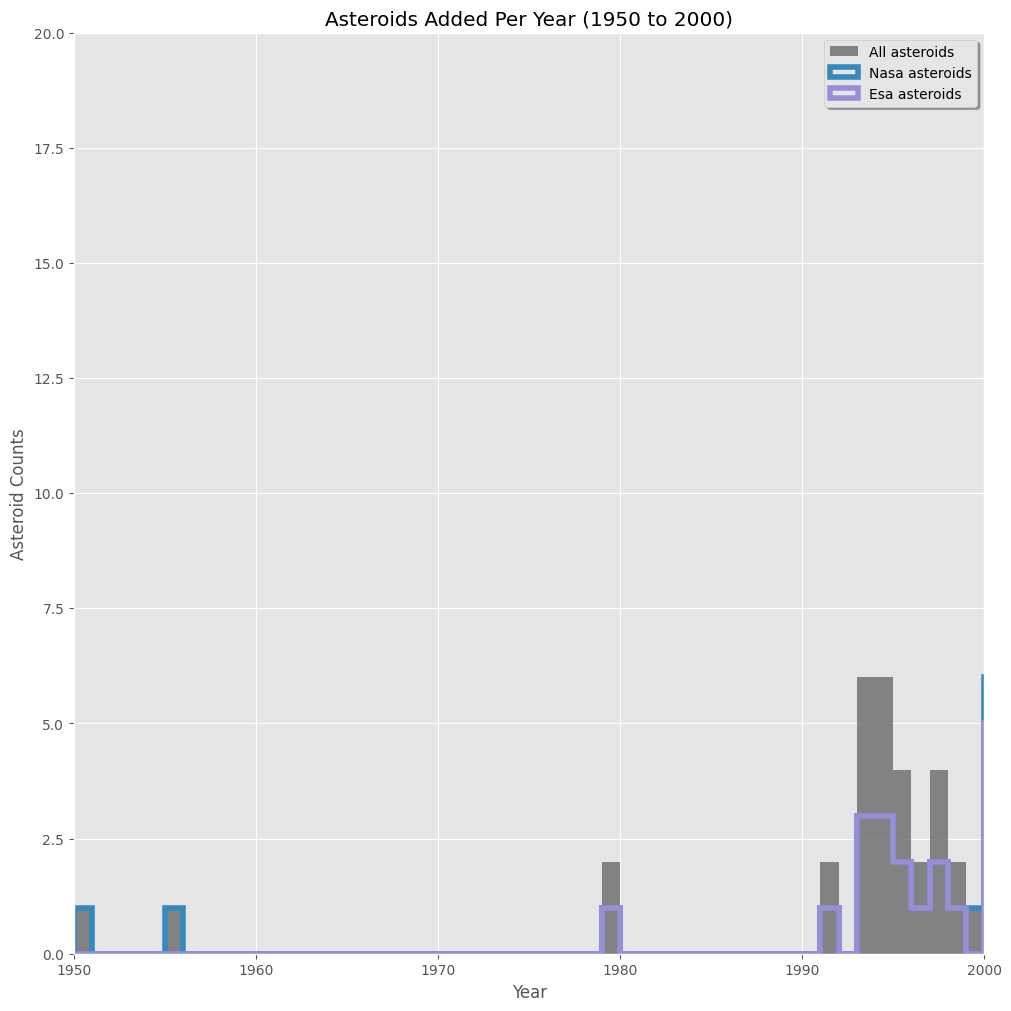

In [6]:
fig, ax = plt.subplots(
    figsize = (10, 10), 
    constrained_layout = True,
)

plt.style.use('ggplot')

# Zoom in to the range 1950 to 2000
ax.set_xlim(1950, 2000)
ax.set_ylim(0, 20)

# All asteroids
my_bins = np.arange(1950, 2026, 1)

ax.hist(all_year,
           bins = my_bins,
           histtype = 'stepfilled',
           facecolor = 'DimGray',
           alpha = 0.8,
           label = "All asteroids")

# Nasa
ax.hist(nasa_year_table['nasa'],
           bins = my_bins,
           histtype = 'step',
           facecolor = 'blue',
           linewidth = 4,
           label = "Nasa asteroids")
# Esa
ax.hist(esa_year_table['esa'],
           bins = my_bins,
           histtype = 'step',
           facecolor = 'red',
           linewidth = 4,
           label = "Esa asteroids")

ax.set_title("Asteroids Added Per Year (1950 to 2000)")
ax.set_xlabel("Year")
ax.set_ylabel("Asteroid Counts")

ax.legend(loc=0, shadow=True);

In [7]:
NASA_SENTRY_table_sum

last_obs,v_inf,ps_max,fullname,ip,des,h,range,last_obs_jd,n_imp,ps_cum,ts_max,diameter,id
str15,str17,str6,str24,str20,str10,str5,str9,str12,int64,str6,object,str7,str8
1979-12-15,23.7606234552547,-2.99,(1979 XB),8.515158e-07,1979 XB,18.54,2056-2113,2444222.5,4,-2.69,0,0.66,bJ79X00B
2022-05-23,15.5694051293592,-5.79,(2022 KK2),0.0001203297828,2022 KK2,28.45,2060-2122,2459722.5,33,-5.59,0,0.0069,bK22K02K
2000-10-03,1.35802744453748,-3.11,(2000 SG344),0.002743395186,2000 SG344,24.79,2069-2122,2451820.5,300,-2.77,0,0.037,bK00SY4G
2012-11-16,11.4626328606267,-6.05,(2012 VS76),1.9442009e-05,2012 VS76,26.95,2081-2120,2456247.5,15,-5.74,0,0.014,bK12V76S
2018-04-09,20.20,-8.95,(2018 GN),3.772e-09,2018 GN,26.19,2102-2102,2458217.5,1,-8.95,0,0.02,bK18G00N
2013-01-12,8.55,-6.16,(2011 TO),2.937e-06,2011 TO,26.32,2064-2064,2456304.5,1,-6.16,0,0.018,bK11T00O
2012-02-21,7.21203952320587,-6.27,(2012 BA102),1.22522146e-05,2012 BA102,26.51,2103-2122,2455978.5,20,-6.03,0,0.017,bK12BA2A
2014-04-27,21.9988508209515,-5.99,(2014 HN197),6.5351e-09,2014 HN197,19.92,2069-2118,2456774.5,12,-5.51,0,0.35,bK14HJ7N
2005-11-22,12.3834503195676,-6.95,(2005 UL6),9.90088e-08,2005 UL6,24.51,2068-2119,2453696.5,6,-6.70,0,0.042,bK05U06L
